In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

1. You will be given a code cell that calculates the coefficients of a quadratic model (yi=a*x^2+bx+c
) between two variables. All code in this cell will be correct. Then in the next code cell, a figure is generated with a scatter plot of the individual data and a line plot of the model prediction. However, the plot is obviously wrong. Make necessary modifications to generate a correct plot.

2. Read in a .csv file to create a DataFrame which contains weather data for Delhi, India in the year 2017. Using the ".plot()" method, generate a single line plot with (time vs. temperature) and (time vs. wind speed). The ".plot()" method is the one connected to a Pandas DataFrame, not the one in the matplotlib.pyplot library.

3. Read in a .csv file to create a DataFrame which contains conversion rates for Euros to U.S. dollars and British Pounds to U.S. dollars over time. Compute non-dimensional percentage growth values for each and plot together on a single plot. (You can use matplotlib.pyplot or the .plot() method connected to a DataFrame).

4. Continuing with the DataFrame of conversion rates, create a new column of Boolean type, which checks whether the conversion rate for one of the currencies was greater than a given value.

5. Continuing Problem 4, make a line plot of the conversion rate for this currency and highlight regions where the conversion rate is larger than a given value, using the function "plt.fill_between"

6. A code cell creates a DataFrame with the following columns. All columns are numerical:

time: A column containing evenly spaced values between 0 and 2pi. Denote them by t0, t1, ...., tn
sin: A column containing the sine function evaluated at those points. I.e.  sin(t0)....sin(tn)
cos: A column containing the cosine function evaluated at those points. I.e. cos(t0), cos(t1),...,cos(tn)
Using the ".diff()" method, create a new column called "d_sin_dt" with the following formula: 
. (sin(tk+1)-sin(tk))/(tk+1-tk)

From calculus, this should be close to cos(tk)
, so plot (time vs. cos) and (time vs. d_sin_dt) together on a single figure to it.

In [13]:
#1. You will be given a code cell that calculates the coefficients of a quadratic model (yi=a*x^2+bx+c)
 #between two variables. All code in this cell will be correct. Then in the next code cell, a figure is 
 #generated with a scatter plot of the individual data and a line plot of the model prediction. However,
 #the plot is obviously wrong. Make necessary modifications to generate a correct plot.

{'a': np.float64(0.23214285714285687), 'b': np.float64(0.14214285714285904), 'c': np.float64(0.5499999999999973)}


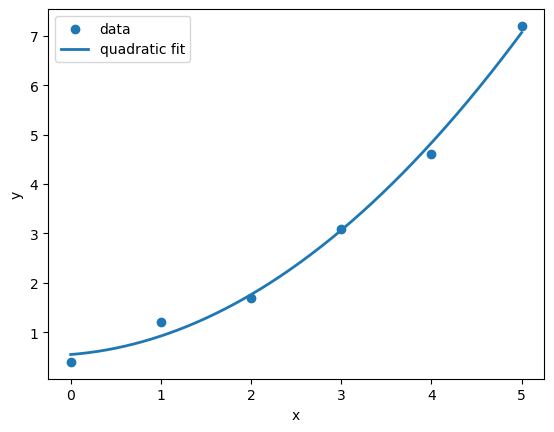

In [14]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0.4, 1.2, 1.7, 3.1, 4.6, 7.2], dtype=float)


# Fit quadratic: returns [a, b, c]
a, b, c = np.polyfit(x, y, deg=2)
print({"a": a, "b": b, "c": c})


# Make smooth prediction curve (CORRECTED)
x_smooth = np.linspace(x.min(), x.max(), 400)
y_hat = a * x_smooth**2 + b * x_smooth + c



plt.scatter(x, y, label="data", zorder=3)
plt.plot(x_smooth, y_hat, label="quadratic fit", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

<Axes: xlabel='date'>

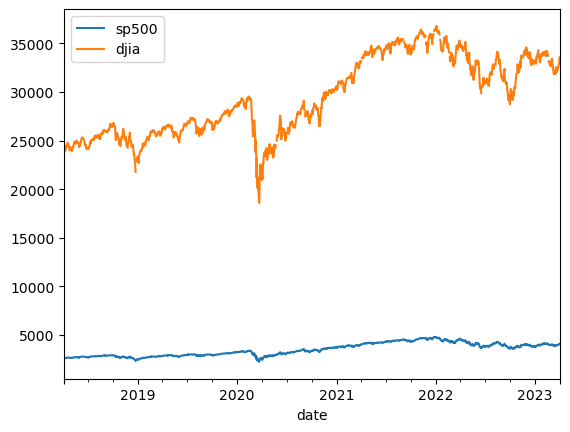

In [44]:
#2. Read in a .csv file to create a DataFrame which contains weather data for Delhi, India in the year 2017. Using the ".plot()" method, generate a single line plot with 
# (time vs. temperature) and (time vs. wind speed).  The ".plot()" method is the one connected to a Pandas DataFrame, not the one in the matplotlib.pyplot library.

df_financial = pd.read_csv("financial.csv")
df_financial["date"] = pd.to_datetime(df_financial["date_str"])

new_df = df_financial.sort_values(by = "date_str", ascending = False)
df_financial[   ["date","sp500","djia"]   ].set_index("date").plot()

In [ ]:
weather =pd.read_csv() # 
# If time column is named something else, change 
weather=

weather[["time", "temperature", "wind_speed"]].set_index("time").plot()


TypeError: read_csv() missing 1 required positional argument: 'filepath_or_buffer'

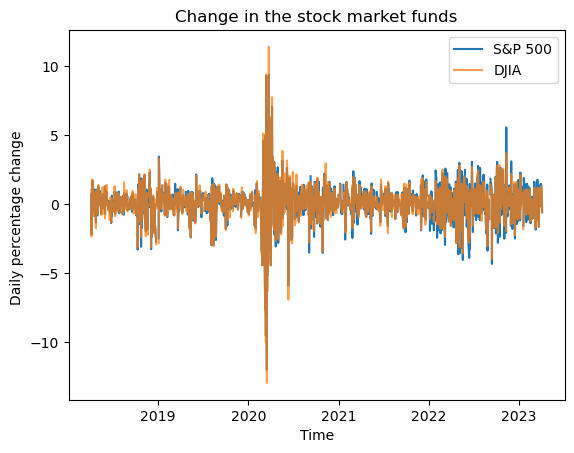

In [28]:
#3. Read in a .csv file to create a DataFrame which contains conversion 
# rates for Euros to U.S. dollars and British Pounds to U.S. dollars over time. 
# Compute non-dimensional percentage growth values for each and plot 
# together on a single plot. (You can use matplotlib.pyplot or the .plot() 
# method connected to a DataFrame).


df_financial["growth_djia"] = (df_financial["djia"].diff()
         / df_financial["djia"].shift(1) )* 100

df_financial["growth_sp500"] = (df_financial["sp500"].diff()/
    df_financial["sp500"].shift(1)) * 100

plt.plot("date", "growth_sp500",
          data = df_financial)
plt.plot("date", "growth_djia",
          data = df_financial,alpha = 0.75)


plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("Change in the stock market funds")
plt.legend(["S&P 500", "DJIA"])
plt.show()

<Axes: xlabel='date'>

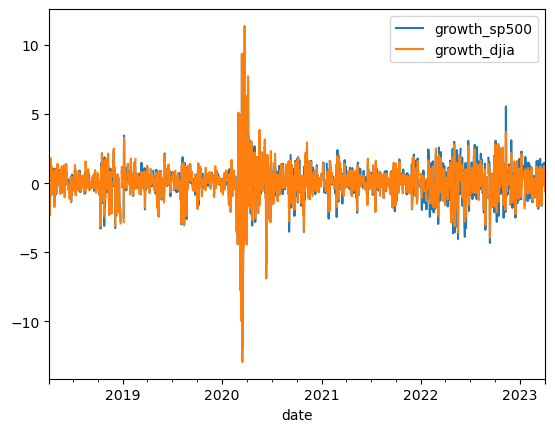

In [41]:
df_financial[["date","growth_sp500","growth_djia"]].set_index("date").plot()

In [39]:
#Continuing with the DataFrame of conversion rates, create a new column of Boolean type,
#  which checks whether the conversion rate for one of the currencies 
# was greater than a given value.

df_financial["gtr_price"]= df_financial["growth_sp500"] > 1


print(df_financial[["date","growth_sp500","gtr_price"]].head())




        date  growth_sp500  gtr_price
0 2018-04-04           NaN      False
1 2018-04-05      0.686281      False
2 2018-04-06     -2.192021      False
3 2018-04-09      0.333657      False
4 2018-04-10      1.672687       True


/var/folders/j_/gdh8lfbx3_78ycg22shk9yc00000gn/T/ipykernel_41880/2470790670.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


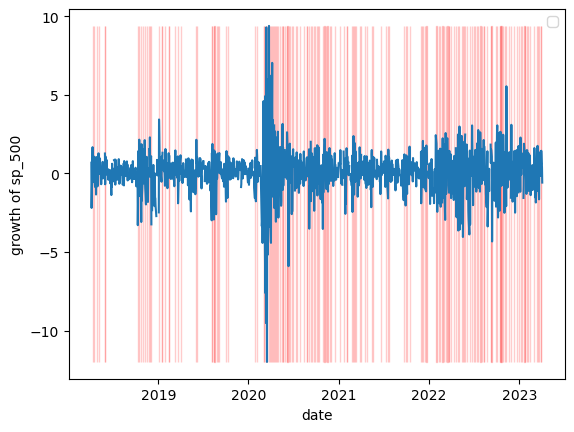

In [42]:
# Continuing Problem 4, make a line plot of the conversion rate for 
# this currency and highlight regions where the conversion rate 
# is larger than a given value, using the function "plt.fill_between"


plt.plot("date","growth_sp500", data=df_financial,
         label="_nolegend_")
plt.xlabel("date")
plt.ylabel("growth of sp_500")

x_vals= df_financial["date"]
y_vals=df_financial["growth_sp500"]
condition=df_financial["gtr_price"]

plt.fill_between(x= x_vals,
                 y1 = y_vals.min(),
                 y2 = y_vals.max(),
                 where = condition,
                 alpha = 0.2,color = "red")
plt.legend()
plt.show()

6.

In [45]:
df_trig["d_sin"] = df_trig["sin"].diff()
df_trig["d_time"] = df_trig["time"].diff()
df_trig["d_sin_dt"] = df_trig["d_sin"] / df_trig["d_time"]

plt.plot("time", "cos", data=df_trig, label="cos(t)")
plt.plot("time", "d_sin_dt", data=df_trig, label="d(sin)/dt", linestyle="--")
plt.xlabel("time")
plt.ylabel("value")
plt.title("Comparison: cos(t) vs. numerical derivative of sin(t)")
plt.legend()
plt.show()



NameError: name 'df_trig' is not defined

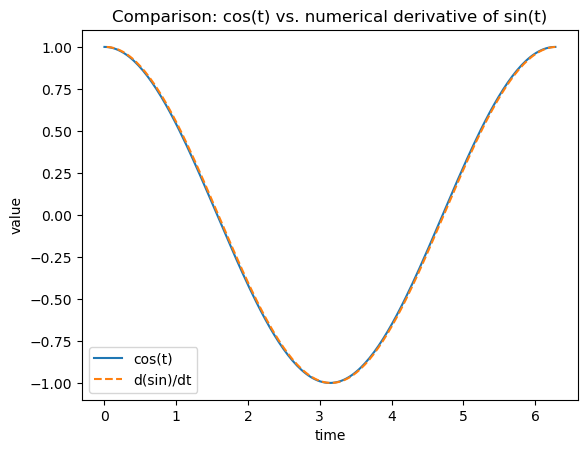

In [46]:
# 1) Create time values between 0 and 2π
N = 200  # number of points (you can increase for smoother curve)
time = np.linspace(0, 2 * np.pi, N)

# 2) Build DataFrame with sine and cosine columns
df_trig = pd.DataFrame({
    "time": time,
    "sin": np.sin(time),
    "cos": np.cos(time)
})

# 3) Use .diff() to compute numerical derivative of sin(t)
df_trig["d_sin"] = df_trig["sin"].diff()
df_trig["d_time"] = df_trig["time"].diff()
df_trig["d_sin_dt"] = df_trig["d_sin"] / df_trig["d_time"]

# 4) Plot cos(t) and d_sin_dt together
plt.plot("time", "cos", data=df_trig, label="cos(t)")
plt.plot("time", "d_sin_dt", data=df_trig, label="d(sin)/dt", linestyle="--")
plt.xlabel("time")
plt.ylabel("value")
plt.title("Comparison: cos(t) vs. numerical derivative of sin(t)")
plt.legend()
plt.show()
